In [3]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cooler
import bioframe
import cooltools
from cooltools.lib import plotting
import cooler as clr
import h5py
import coolbox
from coolbox.api import *
from coolbox.utilities import GenomeRange
from pygenometracks import readBed, readGtf
from pygenometracks.tracks import BedTrack

import glob
from pathlib import Path


%cd /home/varshini/uc_analyses/
import utils, coolbox_helpers
%cd /home/varshini/LoopCall_Analysis_Scripts
import re

warnings.filterwarnings("ignore")

import logging
logging.getLogger('matplotlib.font_manager').disabled = True
from matplotlib.backends.backend_pdf import PdfPages

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [4]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

plt.rcParams.update({
    "text.usetex": False})
plt.rc('pdf',fonttype = 42)

In [5]:
def make_region_plot_mod(region, resolution, microc_file,
                     bw_list, condition_order, gene_annot_name, bedgraph_fname=None, plot_variants=False,
                     file_bottom=None, cmap_chip='tab10', bigwig_bins=1600, autoscale=True, plot_bed=False,
                        variant_track_height=2, custom_valranges=None, plot_genes=True):
    
    """
    Function that makes a plot of a region with Micro-C, ChIP-seq, and Pro-seq.
    
    region: (str) string that specifies region for plotting.
    resolution: (int) resolution of micro-c map used
    highlight_region_list: List of regions of format [chr, start, end] to highlight
    microc_file: (str) file path to micro-c data
    microc_title: (str) title for micro-c
    chip_list_list: List of lists containing paths to bigwigs
    forward_proseq_list: List of paths to forward strand pro-seq files
    reverse_proseq_list: List of paths to reverse strand pro-seq files
    condition_order: List indicating order of conditions to plot. 
    """
    print(region, resolution, microc_file)
    heatmap = Cool(microc_file, file_bottom=file_bottom, resolution=resolution, **MICROC_PLOTTING_PARAMS) 
    frame = heatmap + Spacer(SPACER_HEIGHT*3)
    if plot_bed:
        frame+=NewBed(*BED_PARAMS) + TrackHeight(3) + Spacer(SPACER_HEIGHT)
    #frame +=  BED(finemapped_variant_name, border_only=True, 
    #              alpha=0.1, show_score='yes', linewidth=0.5, display="collapsed", height=1, edgecolor="#0099BB") + Spacer(SPACER_HEIGHT)
    if len(bw_list)>0:
        bigwig_list = coolbox_helpers.make_bigwig_list(bw_list, region, condition_order, autoscale=False)
        cmap_arr = sns.color_palette(cmap_chip, n_colors=len(bigwig_list))

        for i, bigwig in enumerate(bigwig_list):
            if autoscale:
                frame += coolbox_helpers.auto_scale_bigwig(bigwig, region) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)
            else:
                frame += bigwig + MaxValue(custom_valranges[i]) + MinValue(0) + Color(cmap_arr[i]) + Spacer(SPACER_HEIGHT)

    if bedgraph_fname is not None:
        frame += BigWig(bedgraph_fname) + Title("HbF_Base") + Color("#EE7733") + MaxValue(30) + MinValue(0)+ Spacer(SPACER_HEIGHT)
    
    if plot_variants:
        frame+=SNP(finemapped_variant_name, **VARIANTS_PARAMS) \
        + HLines(0, line_width=2, line_style='-',color='k') + Title("HbF GWAS [-log10(p)]")  + TrackHeight(variant_track_height) + Spacer(SPACER_HEIGHT)
    
    if plot_genes:
        annotations = NewBed(*GTF_PARAMS)
#     annotations = GTF(gene_annot_name, color=["#000000"], gene_rows=1, 
#                       filter_named_genes=True, row_filter=None) 
    frame+=annotations

    return frame


def multiplot(mcool1, mcool2, peaks, resolution=5000):
    for index, row in peaks.iterrows():
        plt.figure()
        region_str = get_locus_from_coord(row, flank=200_000)

        # Reverse these
        microc_file1 = mcool1
        microc_file2 = mcool2
        microc_title = f"{region_str} at {resolution}"
        heatmap = Cool(microc_file1, file_bottom=microc_file2,
                       resolution=resolution, **MICROC_PLOTTING_PARAMS) + Title(microc_title)
        frame = heatmap
        annotations = NewBed(*ANNOTATIONS_PARAMS)
        frame += annotations
        frame += XAxis()
        fig = frame.plot(region_str)



In [6]:
class ChromName(Track):
    """
    Track for show chromosome name.

    Parameters
    ----------
    fontsize : float
        Font name to show.

    offset : float
        Offset ratio to the start position.
    """

    DEFAULT_PROPERTIES = {
        "fontsize": 50,
        "offset": 0.45,
    }

    def __init__(self, **kwargs):
        properties = ChromName.DEFAULT_PROPERTIES.copy()
        properties.update(kwargs)
        super().__init__(properties)

    def fetch_data(self, gr: GenomeRange, **kwargs):
        return gr.chrom  # return chromosome name

    def plot(self, ax, gr: GenomeRange, **kwargs):
        x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        ax.set_xlim(gr.start, gr.end)


class NewBed(Track):
    """
    Custom pygenometracks class that allows for control over the aesthetics of gene annotations in
    region plots.
    """

    def __init__(self, coolbox_prop_dict, pygenometracks_prop_dict):
        super().__init__(coolbox_prop_dict)  # init
        self.pygenometracks_object = BedTrack(pygenometracks_prop_dict)

    def fetch_data(self, gr, **kwargs):
        pass

    def plot(self, ax, gr, **kwargs):
        #         x = gr.start + self.properties['offset'] * (gr.end - gr.start)
        #         ax.text(x, 0, gr.chrom, fontsize=self.properties['fontsize'])
        #         ax.set_xlim(gr.start, gr.end)
        self.pygenometracks_object.plot(ax, gr.chrom, gr.start, gr.end)
        ax.set_xlim([gr.start, gr.end])

# define the bigwig and RNAseq files 

def get_chip_list(base_dir='/mnt/coldstorage/Varshmallow/', phase=1, phase2=None, 
                  include=['RNASeq', 'ATAC', 'H3K27ac', 'H3K4me1']):

    chip_dir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/'
    chip_dict = {}
    chip_dict['RNASeq'] = f'{base_dir}Blood_RNAseq/Phase{phase}_RNA_chr.bw'
    
    # ATAC-Seq
    chip_dict[f'ATAC_P{phase}'] = f'{base_dir}Blood_ATAC/Phase{phase}_ATAC.bw'
    
    chip_dict['NFE2_K562']='/mnt/md0/varshini/Analysis/Blood/other_datasets/NFE2/NFE2_K562_ENCFF025UPR.bigWig'
    chip_dict['NFE2_d8']='/mnt/md0/varshini/Analysis/Blood/other_datasets/NFE2/d8_NFE2.bw'
    
    chip_dict['NFE2_RNA']=os.path.join(rnaseq_dir, "NFE2_P3_rmdup_CPM.bw")
    chip_dict['AAVS1_RNA']=os.path.join(rnaseq_dir, "AAVS1_P3_rmdup_CPM.bw")
    
    if phase2 is not None:
        chip_dict['ATACSeq2'] = f'{base_dir}Blood_ATAC/Phase{phase2}_ATAC.bw'
        chip_dict['RNASeq2'] = f'{base_dir}Blood_RNAseq/Phase{phase2}_RNA_chr.bw'
        
    # Histone ChIP
    directory = os.fsencode(chip_dir)
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        rm = re.match(r'\w*CTCF\S*', filename)
        if rm is not None:
            chip_dict['CTCF'] = f'{chip_dir}{rm.group(0)}'

        rm = re.match(r'\w*H3K27ac\S*', filename)
        if rm is not None:
            chip_dict['H3K27ac']  = f'{chip_dir}{rm.group(0)}'

        rm = re.match(r'\w*H3K4me1\S*', filename)
        if rm is not None:
            chip_dict['H3K4me1'] = f'{chip_dir}{rm.group(0)}'
            
        rm = re.match(r'\w*GATA1\S*', filename)
        if rm is not None:
            chip_dict['GATA1'] = f'{chip_dir}{rm.group(0)}'
    if phase2 is not None:
        chip_dir2 = os.path.join(base_dir, 'Blood_ChIP', f'P{phase2}/')
        directory = os.fsencode(chip_dir2)
        for file in os.listdir(directory):
            filename = os.fsdecode(file)
            rm = re.match(r'\w*CTCF\S*', filename)
            if rm is not None:
                chip_dict['CTCF_2'] = f'{chip_dir2}{rm.group(0)}'

            rm = re.match(r'\w*H3K27ac\S*', filename)
            if rm is not None:
                chip_dict['H3K27ac_2']  = f'{chip_dir2}{rm.group(0)}'

            rm = re.match(r'\w*H3K4me1\S*', filename)
            if rm is not None:
                chip_dict['H3K4me1_2'] = f'{chip_dir2}{rm.group(0)}'

            rm = re.match(r'\w*GATA1\S*', filename)
            if rm is not None:
                chip_dict['GATA1_2'] = f'{chip_dir2}{rm.group(0)}'
        
    chip_list = [chip_dict[key] for key in include]
    return chip_list


In [7]:
# define the bigwig and RNAseq files 
base_dir = '/mnt/coldstorage/Varshmallow/'
base_dir = '/mnt/coldstorage/Varshmallow/'
rnaseq_dir = '/mnt/md1/varshini/Blood/rnaseq_v2/aligned'
# define the bigwig and RNAseq files 
base_dir = '/mnt/coldstorage/Varshmallow/'

def get_chip_list(base_dir='/mnt/coldstorage/Varshmallow/', phase=1, phase2=None, 
                  include=['RNASeq', 'ATAC', 'H3K27ac', 'H3K4me1']):

    chip_dict = {}
    chip_dict[f'RNASeq_P{phase}'] = f'{base_dir}Blood_RNAseq/Phase{phase}_RNA_chr.bw'
    
    # ATAC-Seq
    chip_dict[f'ATAC_P{phase}'] = f'{base_dir}Blood_ATAC/Phase{phase}_ATAC.bw'
    
    chip_dict['NIPBL'] = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/GSM8864683_HUDEP-2_NIPBL_rep1_2_mean.bw'
 
    # GATA-1 
    
    chip_dict['NFE2_K562']='/mnt/md0/varshini/Analysis/Blood/other_datasets/NFE2/NFE2_K562_ENCFF025UPR.bigWig'
    chip_dict['NFE2_d8']='/mnt/md0/varshini/Analysis/Blood/other_datasets/NFE2/d8_NFE2.bw'
    
    chip_dict['NFE2_RNA']=os.path.join(rnaseq_dir, "NFE2_P3_rmdup_CPM.bw")
    chip_dict['AAVS1_RNA']=os.path.join(rnaseq_dir, "AAVS1_P3_rmdup_CPM.bw")
    
    if phase2 is not None:
        chip_dict[f'ATAC_P{phase2}'] = f'{base_dir}Blood_ATAC/Phase{phase2}_ATAC.bw'
        chip_dict[f'RNASeq_P{phase2}'] = f'{base_dir}Blood_RNAseq/Phase{phase2}_RNA_chr.bw'
        
    # Histone ChIP
    chip_dir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/bigwigs/'

    directory = os.fsencode(chip_dir)
    
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        rm = re.match(rf'\w*P{phase}_CTCF\S*', filename)
        if rm is not None:
            chip_dict[f'CTCF_P{phase}'] = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K27ac\S*', filename)
        if rm is not None:
            chip_dict[f'H3K27ac_P{phase}']  = f'{chip_dir}{rm.group(0)}'

        rm = re.match(rf'\w*P{phase}_H3K4me1\S*', filename)
        if rm is not None:
            chip_dict[f'H3K4me1_P{phase}'] = f'{chip_dir}{rm.group(0)}'
       
        rm = re.match(r'\w*GATA1\S*', filename)
        if rm is not None:
            chip_dict[f'GATA1'] = f'{base_dir}Blood_ChIP/P{phase}/{rm.group(0)}'
            
        
    if phase2 is not None:
        for file in os.listdir(directory):
            filename = os.fsdecode(file)
            rm = re.match(rf'\w*P{phase2}_CTCF\S*', filename)
            if rm is not None:
                chip_dict[f'CTCF_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K27ac\S*', filename)
            if rm is not None:
                chip_dict[f'H3K27ac_P{phase2}']  = f'{chip_dir}{rm.group(0)}'

            rm = re.match(rf'\w*P{phase2}_H3K4me1\S*', filename)
            if rm is not None:
                chip_dict[f'H3K4me1_P{phase2}'] = f'{chip_dir}{rm.group(0)}'

        
    chip_list = [chip_dict[key] for key in include]
    return chip_list


In [8]:
# NFE2/AAVS1 regions

basedir = '/mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/'
nfe2_name = os.path.join(basedir, 'NFE2_P3_microc.50.mcool')
aavs1_name = os.path.join(basedir, 'AAVS1_P3_microc.50.mcool')

savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v4/fig4')

In [23]:
GTF_FILENAME = "/mnt/md0/varshini/Gene_Annotations/refSeqSelect.bed"

# Define plotting aesthetics as global variables
HIGHLIGHT_PARAMS = {"color":"gray",
                   "alpha":0.5,
                   "border_line":False}

MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"log10",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":-0.5,
                          "min_value":-4.5}


SPACER_HEIGHT = 0.4
GTF_PARAMS = [
     {"height":2},
    {"file":GTF_FILENAME,
     "max_labels":1000,
    "merge_transcripts":True,       #"gene_style":"normal",
    "border_only":"true",
     "color":"#000000"
    }] # PATH TO BED FILE OF GENE ANNOTATIONS


tf_acrs_name = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/erythroid_tracks/classifications/tf_acrs_sorted_enhancernotpromoternotctcf.bed'
resolution=2000

BED_PARAMS = [{"height":1},
                      {"file": tf_acrs_name,
                      "max_labels":1,
                       "gene_rows":1,
                      "border_only":"true"}]

Error message: could not convert string to float: 'ATF4'
Only the first 4 fields will be used.


chr9:5344067-5644067 2000 /mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/AAVS1_P3_microc.50.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33674.58it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08


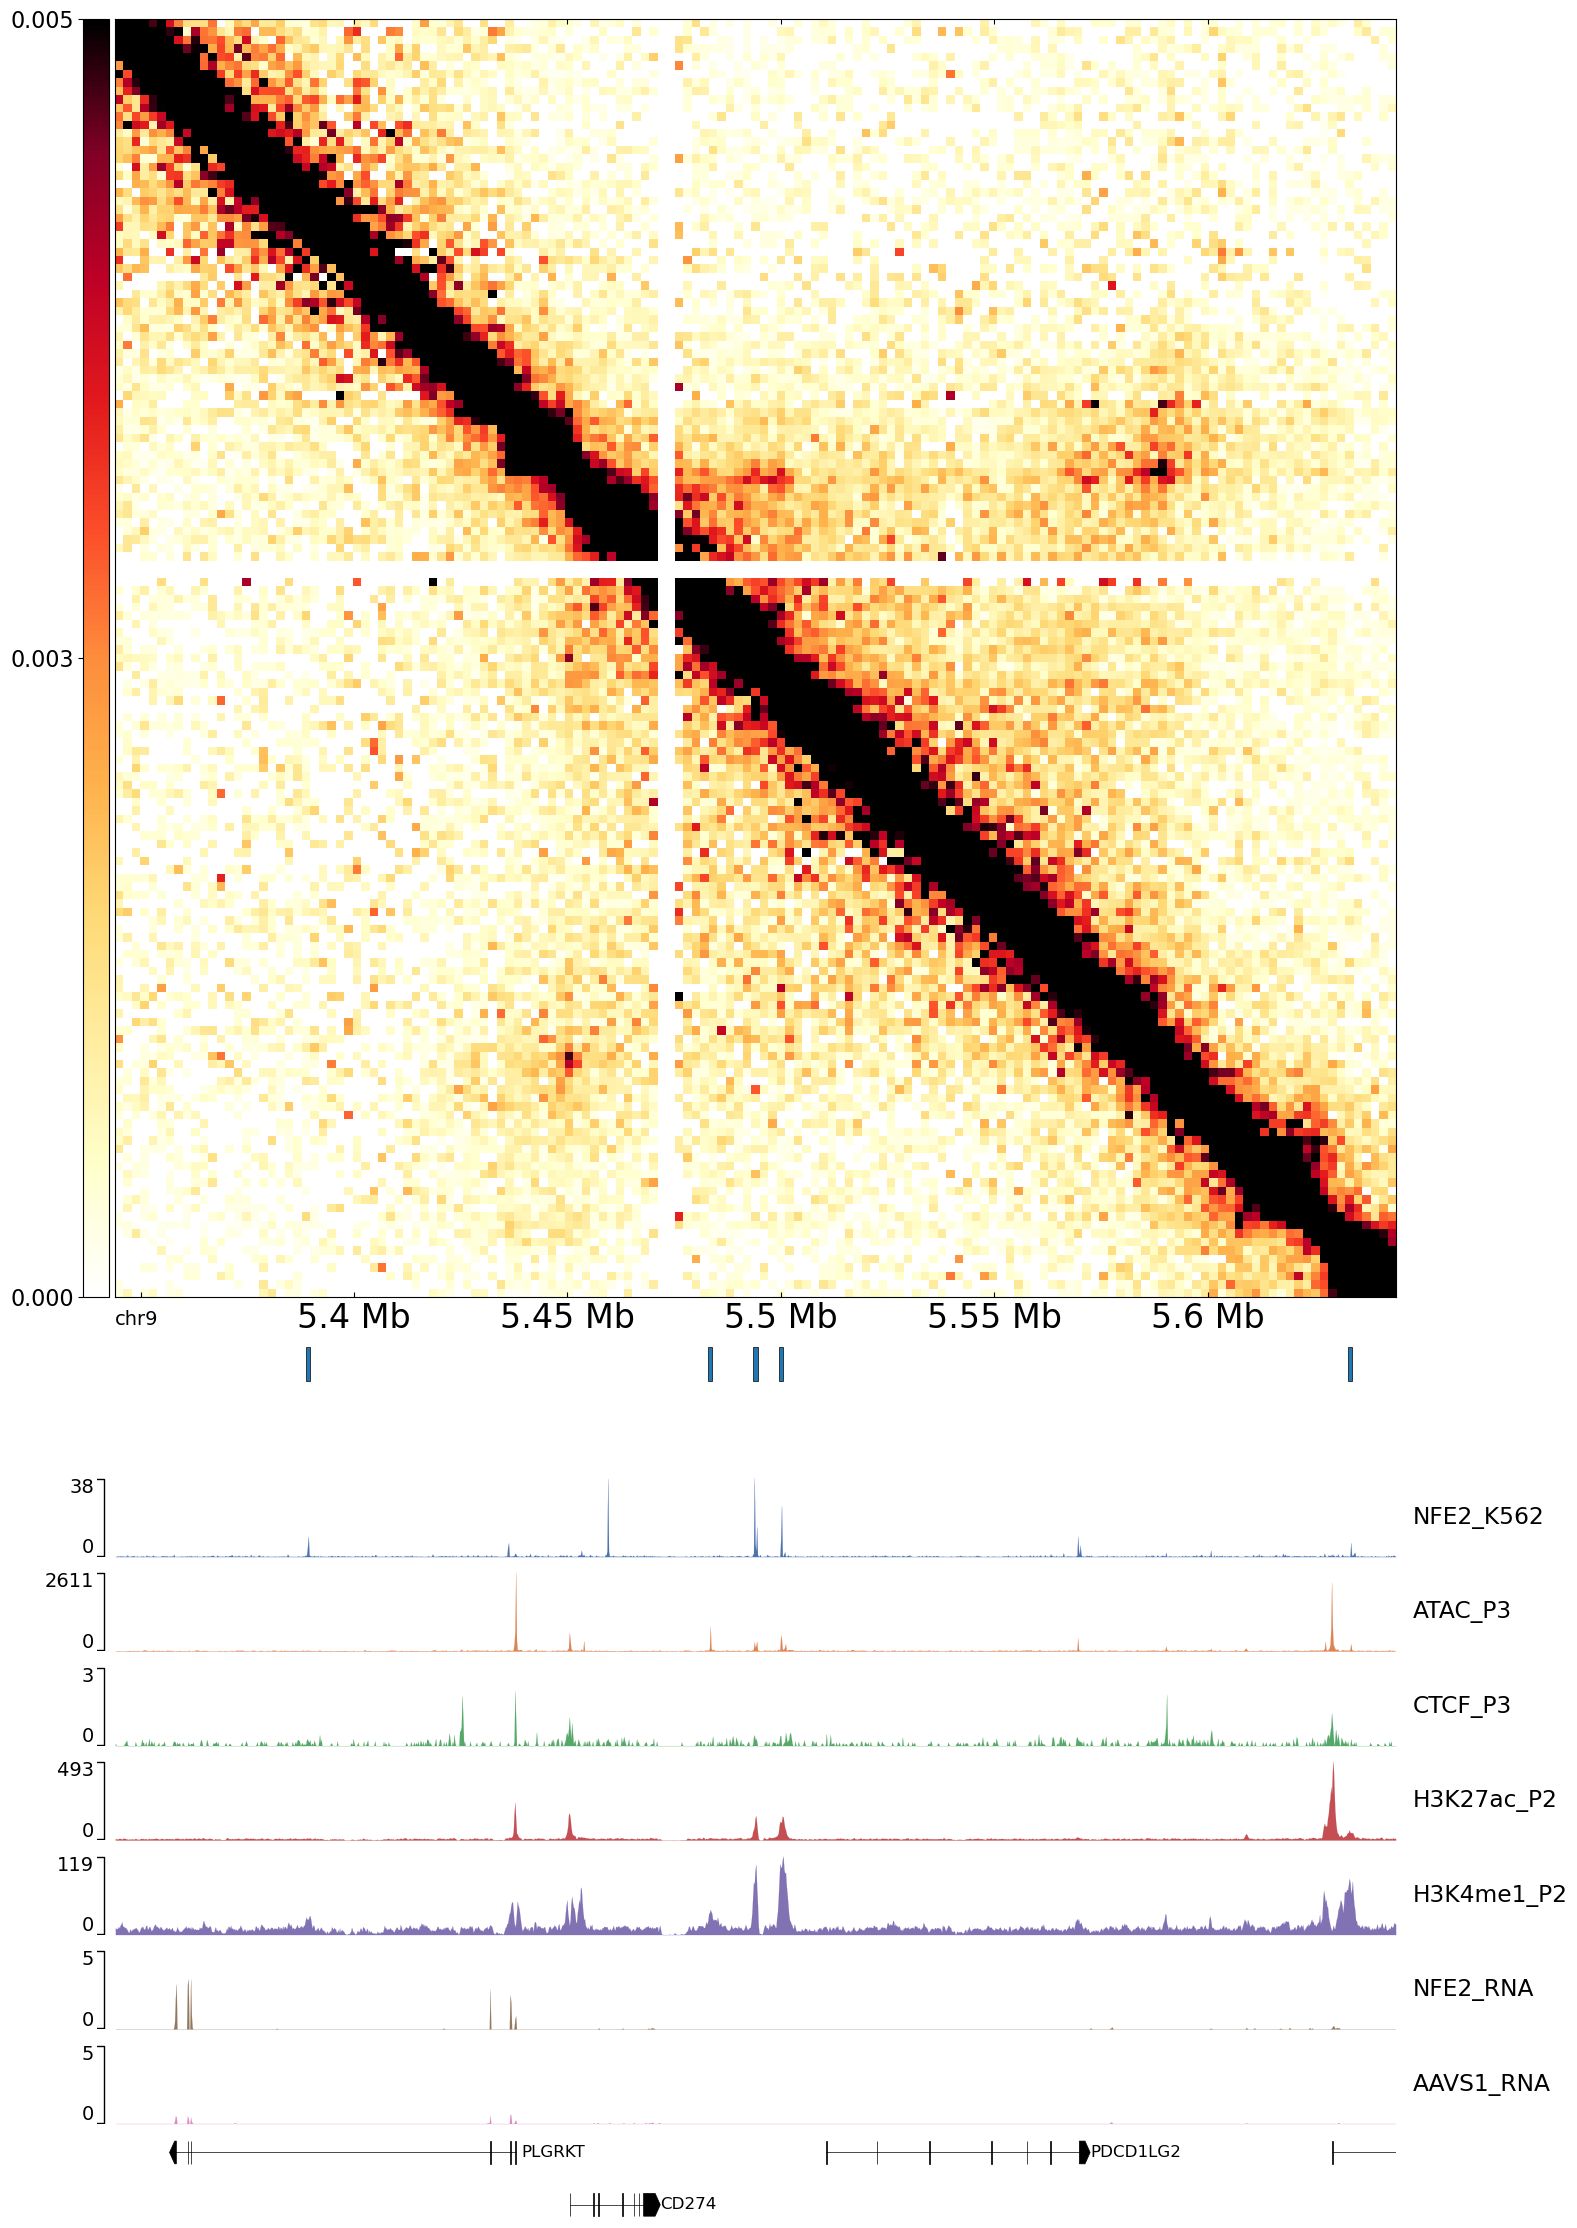

In [24]:
region_str = 'chr9:5344067-5644067'
reso=2000
incl= ['NFE2_K562','ATAC_P3', 'CTCF_P3', 'H3K27ac_P2','H3K4me1_P2','NFE2_RNA','AAVS1_RNA']
chip_list = get_chip_list(include=incl, phase=3, phase2=2)


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.005,
                          "min_value":0,
                          "fontsize":14}
frame = make_region_plot_mod(region_str, reso, aavs1_name,
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=False,
                         file_bottom = nfe2_name, cmap_chip="deep", autoscale=False,
                        custom_valranges = [38, 2611, 3, 493, 119, 5, 5])
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, f"nfe2_2.svg"))                  
fig

Error message: could not convert string to float: 'ATF4'
Only the first 4 fields will be used.


chr7:11152122-11402122 3200 /mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/AAVS1_P3_microc.50.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33763.34it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 1.08,-0.08


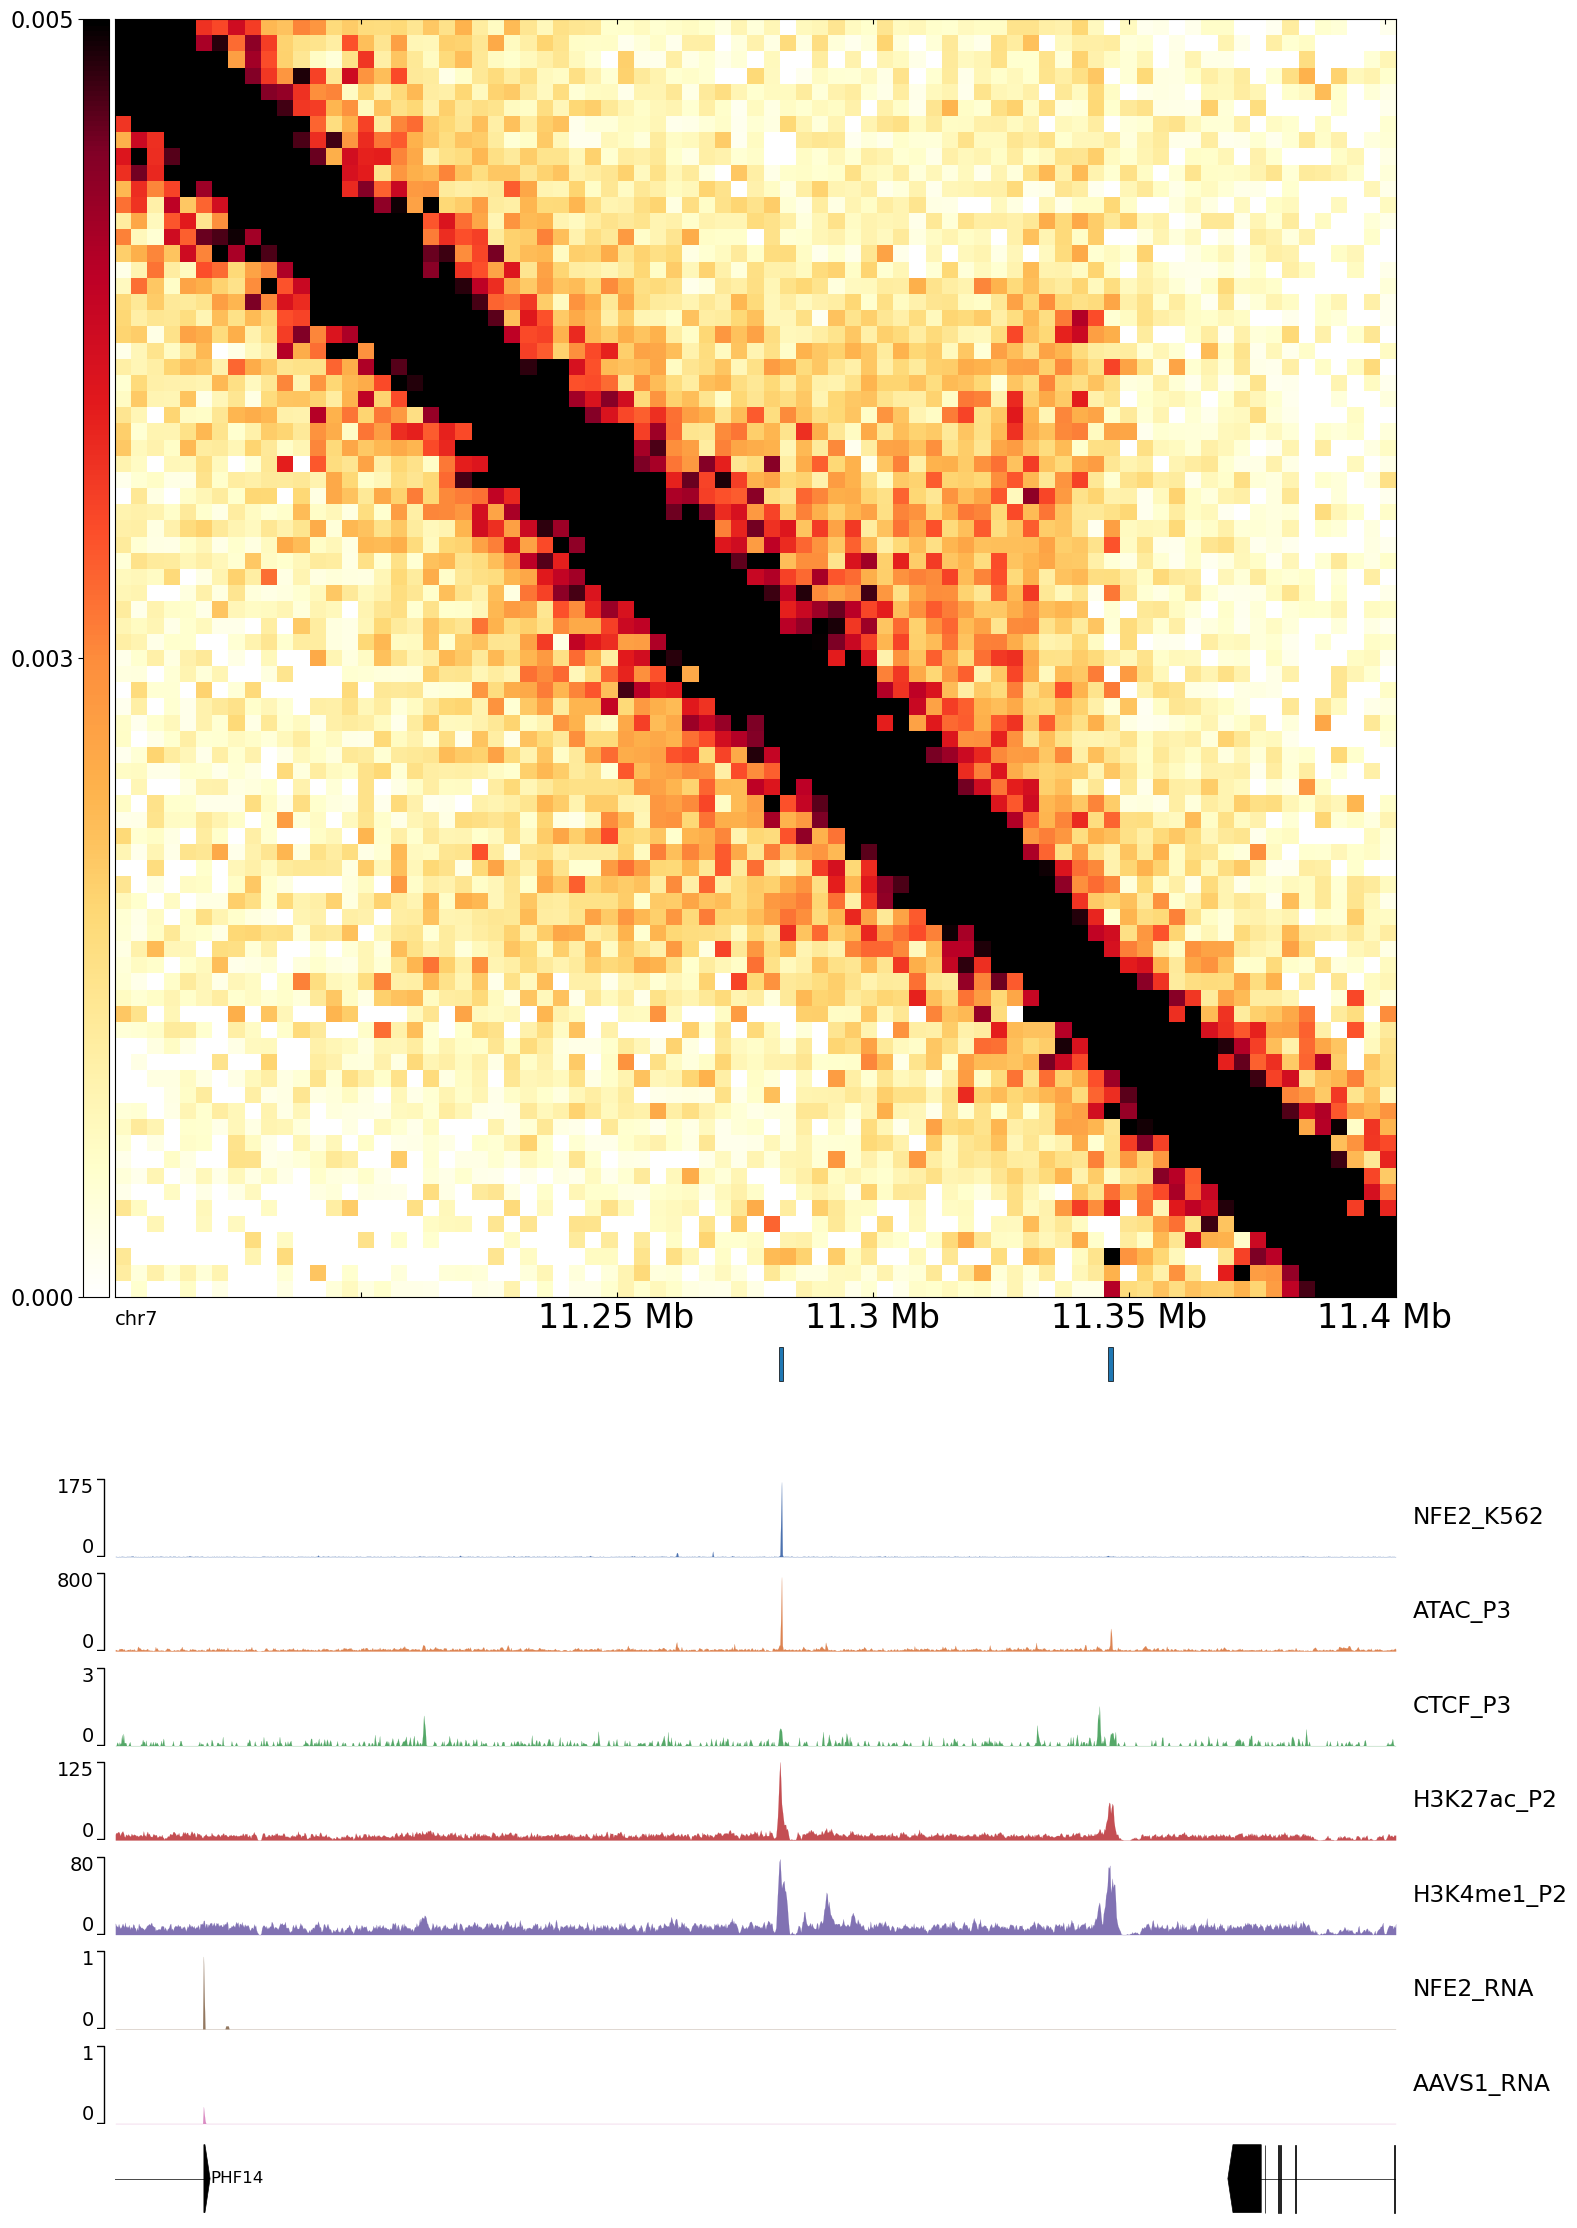

In [25]:


region_str ='chr7:11152122-11402122'
reso=3200
incl= ['NFE2_K562','ATAC_P3', 'CTCF_P3', 'H3K27ac_P2','H3K4me1_P2','NFE2_RNA','AAVS1_RNA']
chip_list = get_chip_list(include=incl, phase=3, phase2=2)


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.005,
                          "min_value":0,
                          "fontsize":14}
frame = make_region_plot_mod(region_str, reso, aavs1_name,
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=False,
                         file_bottom = nfe2_name, cmap_chip="deep", autoscale=False,
                            custom_valranges = [175, 800, 3, 125, 80, 1, 1])
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, f"nfe2_1.svg"))                  
fig

Error message: could not convert string to float: 'ATF4'
Only the first 4 fields will be used.


chr8:108702659-109472659 5000 /mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/AAVS1_P3_microc.50.mcool


100%|██████████████████████████████████| 22438/22438 [00:02<00:00, 11068.90it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 3.38,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 5.68,-0.08


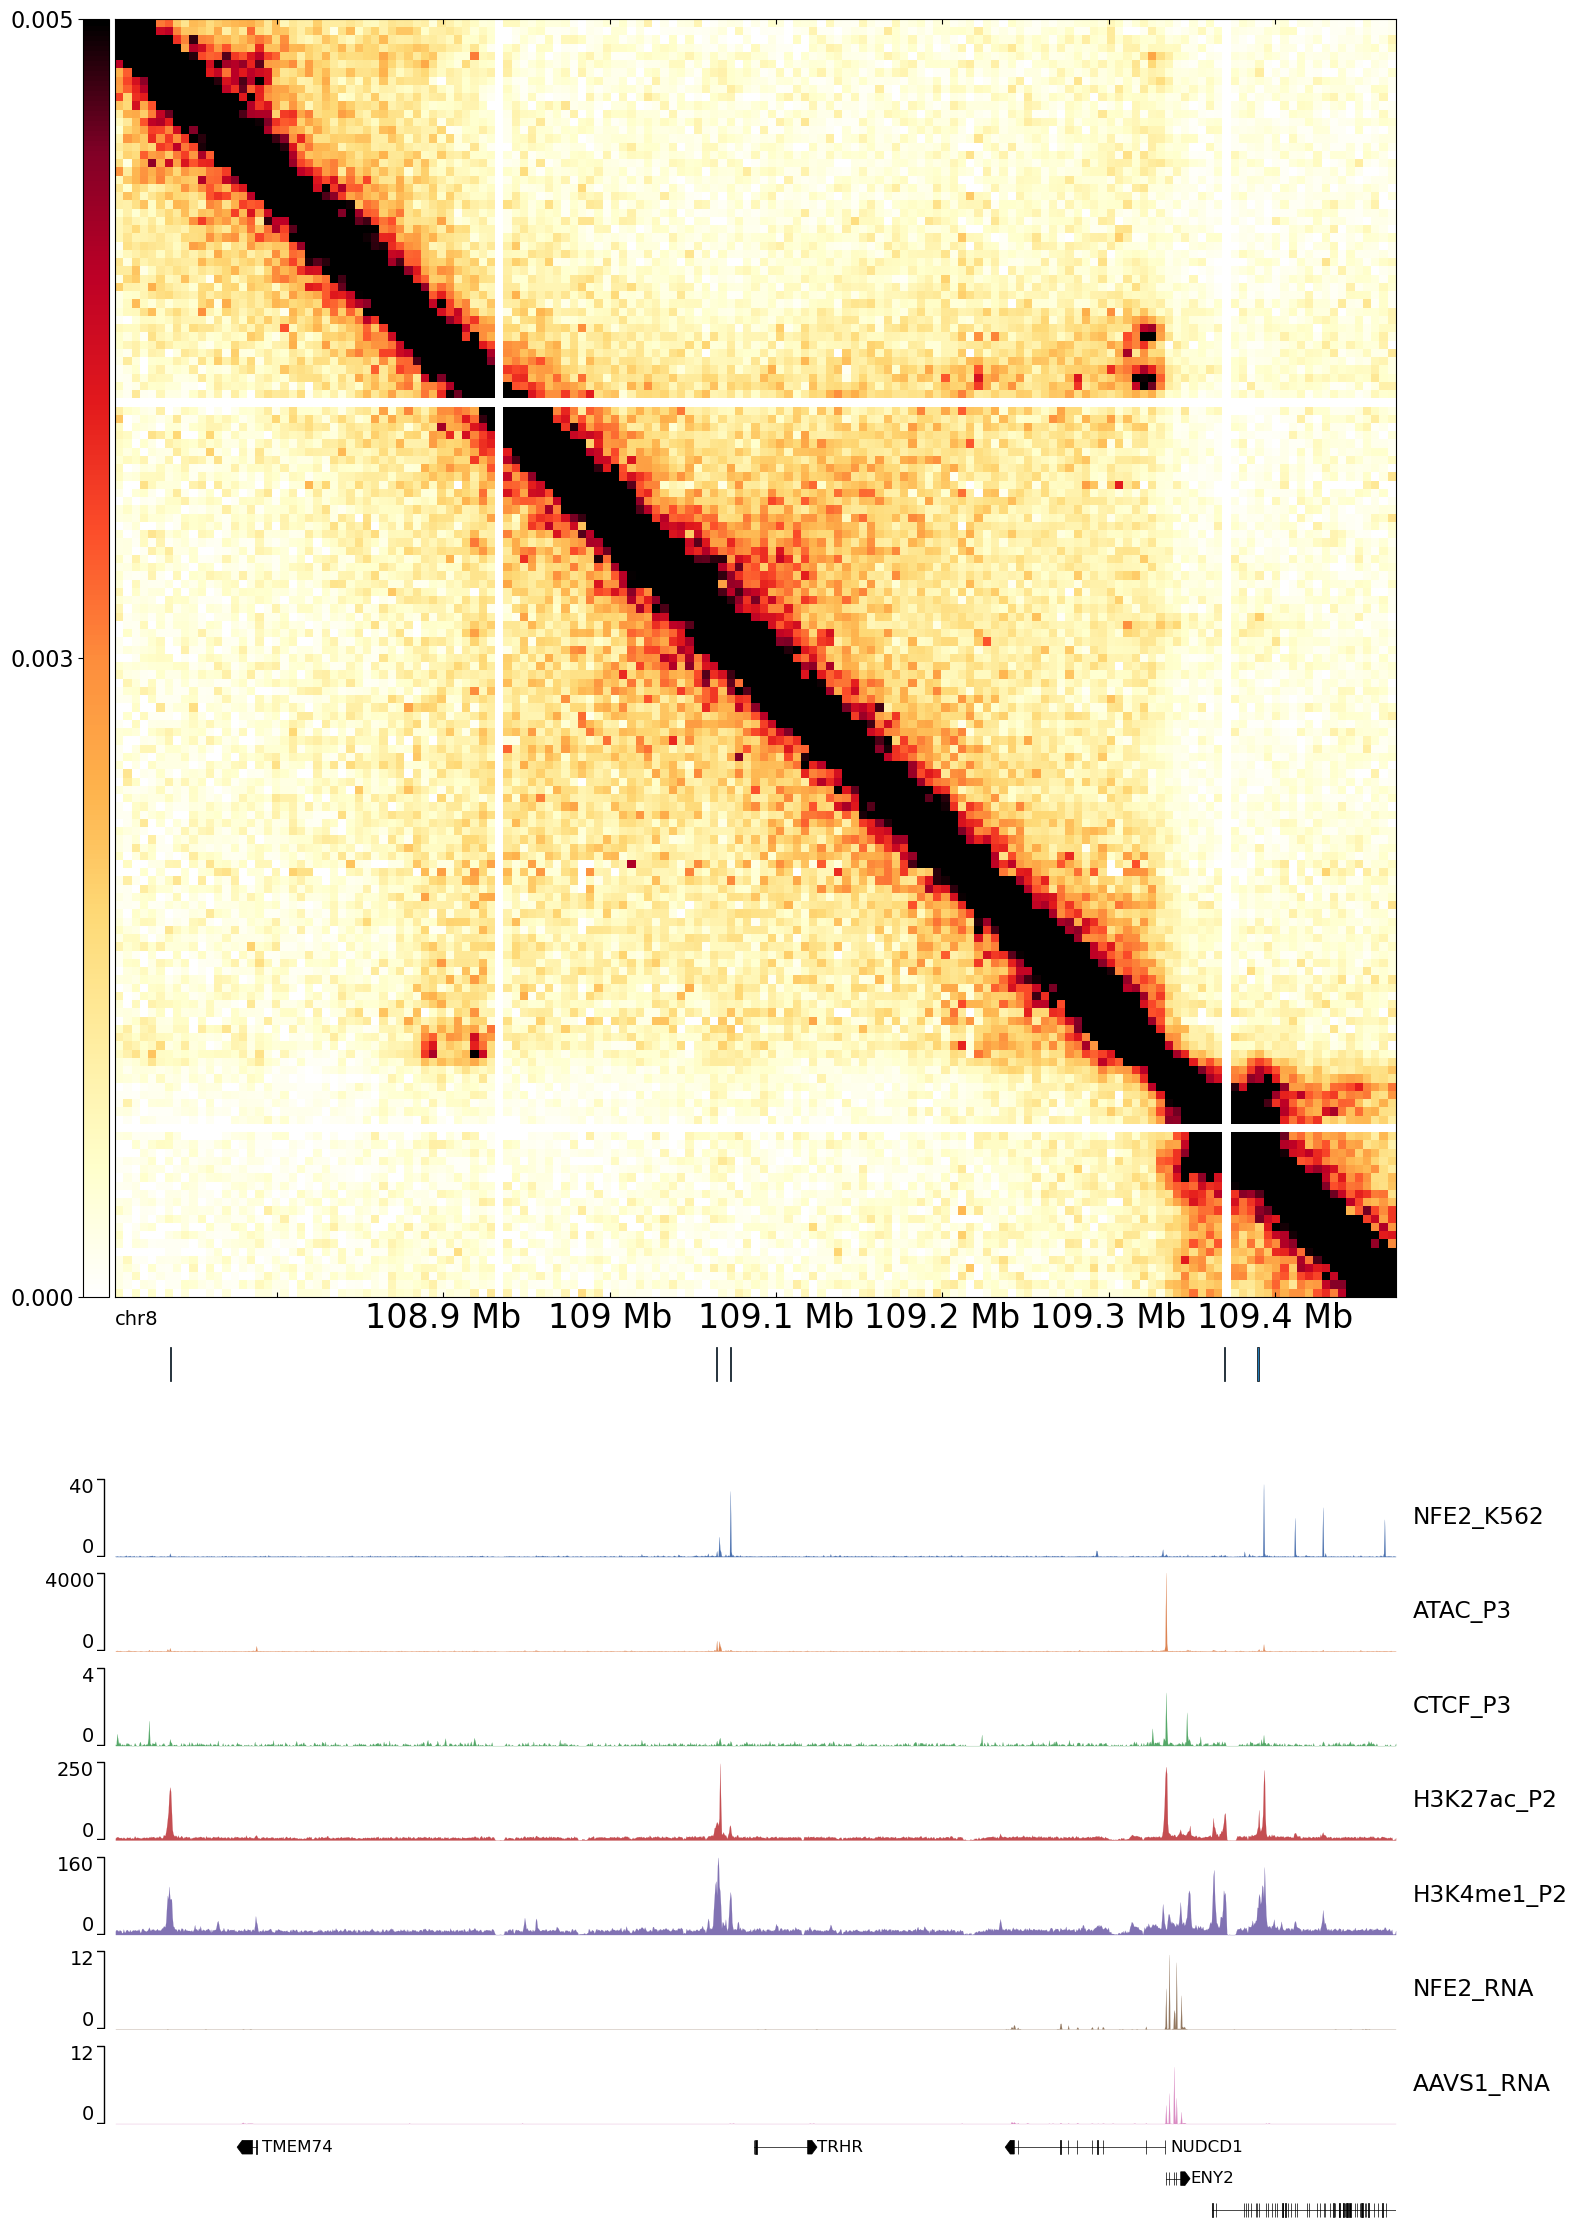

In [26]:
region_str = 'chr8:108702659-109472659'

reso=5000
incl= ['NFE2_K562','ATAC_P3', 'CTCF_P3', 'H3K27ac_P2','H3K4me1_P2','NFE2_RNA','AAVS1_RNA']
chip_list = get_chip_list(include=incl, phase=3, phase2=2)


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.005,
                          "min_value":0,
                          "fontsize":14}
frame = make_region_plot_mod(region_str, reso, aavs1_name,
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=False,
                         file_bottom = nfe2_name, cmap_chip="deep", autoscale=False,
                            custom_valranges = [40, 4000, 4, 250, 160, 12, 12])
fig = frame.plot(region_str)
#fig.savefig(os.path.join(savedir, f"nfe2_3.svg"))                  
fig

chr8:108892659-109252659 5000 /mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/AAVS1_P3_microc.50.mcool


100%|██████████████████████████████████| 22438/22438 [00:00<00:00, 33623.50it/s]


bar is on
32.45700000000001
37.2
You've reached the modified Cool class!


DEBUG:pygenometracks.tracks.GenomeTrack:ylim 1.08,-0.08


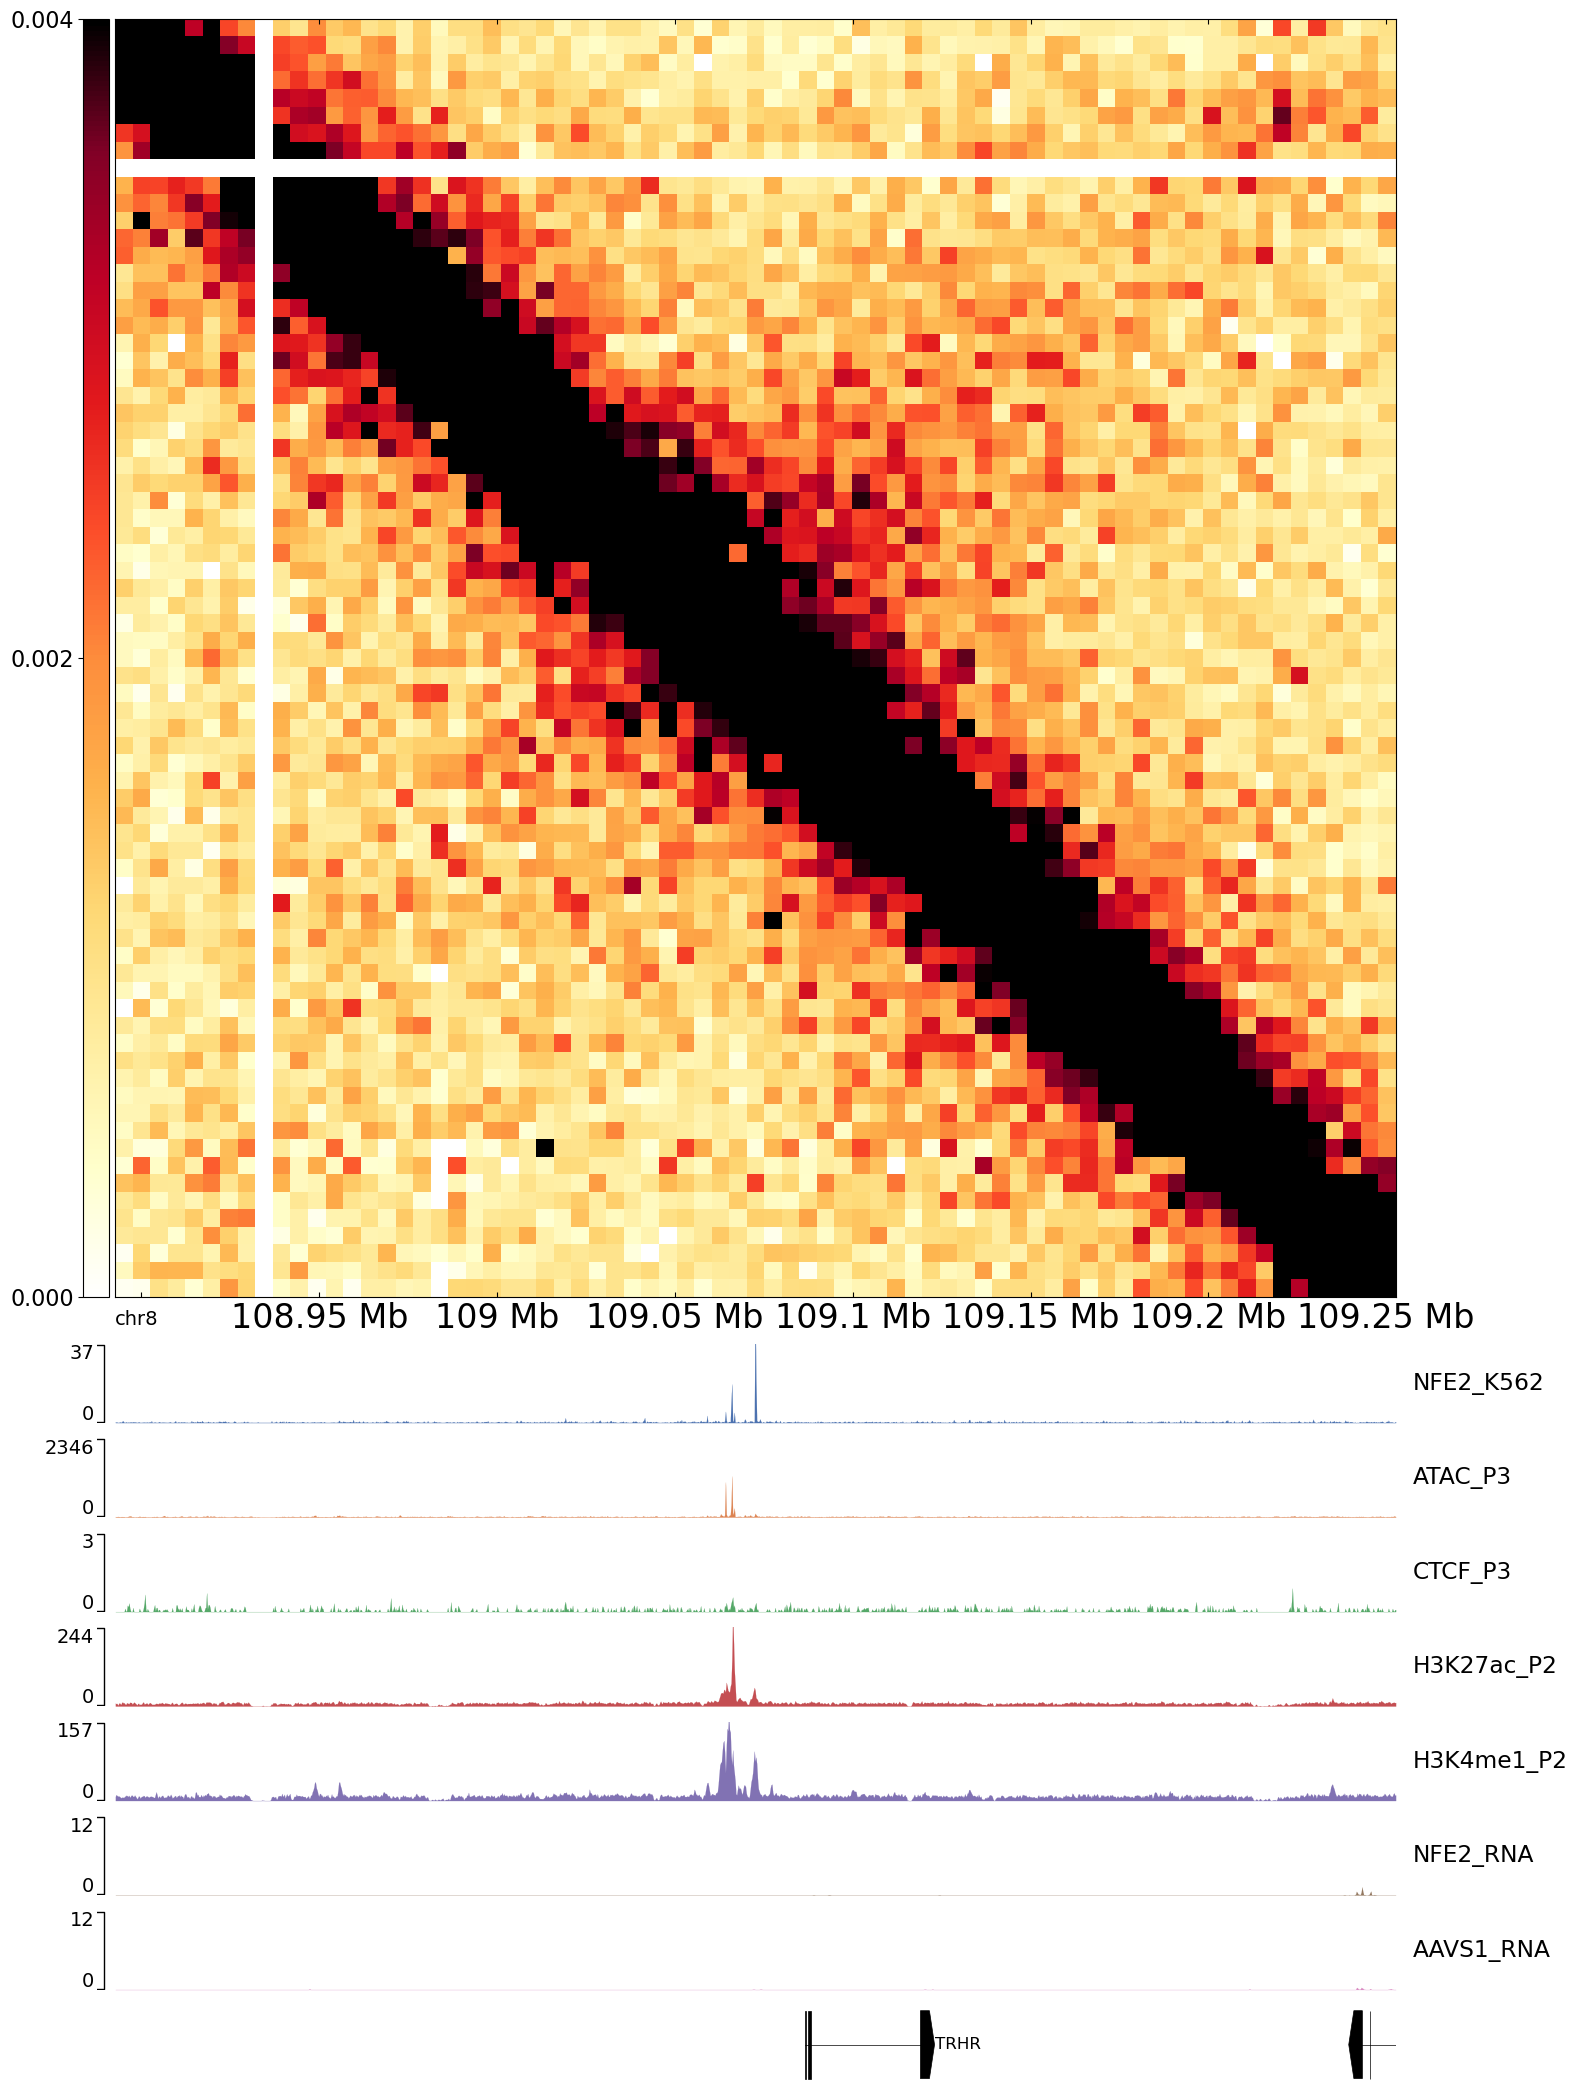

In [27]:
region_str = 'chr8:108892659-109252659'

reso=5000
incl= ['NFE2_K562','ATAC_P3', 'CTCF_P3', 'H3K27ac_P2','H3K4me1_P2','NFE2_RNA','AAVS1_RNA']
chip_list = get_chip_list(include=incl, phase=3, phase2=2)


MICROC_PLOTTING_PARAMS = {"style":"matrix",
                          "transform":"linear",
                          "depth_ratio":"full",
                          "balance":True,
                          "cmap":"fall",
                          "max_value":0.004,
                          "min_value":0,
                          "fontsize":14}
frame = make_region_plot_mod(region_str, reso, aavs1_name,
                         chip_list, condition_order=incl, gene_annot_name=GTF_FILENAME,
                        bedgraph_fname=None, plot_variants=False, plot_bed=False,
                         file_bottom = nfe2_name, cmap_chip="deep", autoscale=False,
                            custom_valranges = [37, 2346, 3, 244, 157, 12, 12])
fig = frame.plot(region_str)
fig.savefig(os.path.join(savedir, f"nfe2_3_inset.svg"))                  
fig